# Dampak Simulasi Kebijakan terhadap Penduduk Miskin Kabupaten/Kota Sulawesi Tenggara

Notebook ini melanjutkan notebook pertama (`Analisis_Forkestra2026_Sultra.ipynb`). Hasil simulasi tingkat provinsi, yaitu perubahan harga ikan konsumen, harga produsen, kapasitas tangkap, dan harga pangan lain pada bulan sasaran, kita turunkan ke 17 kabupaten/kota untuk melihat siapa yang terdampak dan berapa besar perubahan jumlah penduduk miskinnya.

Dua saluran dampak dihitung terpisah:

1. **Saluran konsumen.** Perubahan harga ikan dan pangan lain menggeser garis kemiskinan. Bobotnya mengikuti kota IHK acuan terdekat dari setiap kabupaten/kota.
2. **Saluran produsen.** Perubahan penerimaan nelayan (harga produsen dikali kapasitas tangkap) menggeser pendapatan rumah tangga sesuai ketergantungan wilayah pada perikanan tangkap.

Urutan kerja kita:

1. Menyiapkan lingkungan kerja, folder keluaran, dan fungsi bantu.
2. Memuat paket data dan keluaran notebook pertama.
3. Menyusun profil kemiskinan kabupaten/kota.
4. Mengkalibrasi distribusi pengeluaran tiap wilayah dan memvalidasinya dengan indeks kedalaman kemiskinan (P1).
5. Mengukur paparan harga (konsumen) dan paparan pendapatan (produsen).
6. Mereplikasi simulasi provinsi dan menurunkannya ke kabupaten/kota.
7. Menguji ketidakpastian.
8. Menyusun tipologi prioritas wilayah.
9. Menyimpan dan memaketkan keluaran.

Tabel dan grafik memakai bahasa Inggris; penjelasan dan interpretasi otomatis memakai bahasa Indonesia dan disusun dari angka hasil perhitungan.

## Langkah 1. Lingkungan kerja, folder keluaran, dan fungsi bantu

Huruf grafik diatur ke Times New Roman ukuran 13. Bila berkas `times.ttf` ditaruh di subfolder `fonts`, berkas itu didaftarkan otomatis. Peta digambar langsung dari berkas GeoJSON tanpa pustaka geospasial tambahan.

In [1]:
import os, sys, re, glob, json, zipfile, shutil, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import norm
from scipy.optimize import brentq

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)

for pola in ['fonts/*.ttf', 'fonts/*.TTF', 'C:/Windows/Fonts/times*.ttf', os.path.expanduser('~/Library/Fonts/Times*.ttf'),
             '/Library/Fonts/Times*.ttf', '/usr/share/fonts/**/[Tt]imes*.ttf', os.path.expanduser('~/.fonts/*.ttf')]:
    for berkas in glob.glob(pola, recursive=True):
        try:
            font_manager.fontManager.addfont(berkas)
        except Exception:
            pass
tersedia = {f.name for f in font_manager.fontManager.ttflist}
FONT_UTAMA = next((f for f in ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'TeX Gyre Termes', 'DejaVu Serif'] if f in tersedia), 'DejaVu Serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': [FONT_UTAMA, 'Times New Roman', 'DejaVu Serif'], 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'figure.titlesize': 13, 'mathtext.fontset': 'stix', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 100, 'savefig.dpi': 300})
RNG = np.random.default_rng(20260922)

USE_GDRIVE = False
DI_COLAB = 'google.colab' in sys.modules
if USE_GDRIVE and DI_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Forkestra2026'
else:
    BASE_DIR = os.getcwd()
OUT_DIR = os.path.join(BASE_DIR, 'output_forkestra2026_kabkota')
SUB = {k: os.path.join(OUT_DIR, k) for k in ['figures', 'tables', 'interpretations']}
for p in SUB.values():
    os.makedirs(p, exist_ok=True)
TABEL, GAMBAR, TAFSIR = {}, {}, {}

def angka(x, d=2):
    try:
        x = float(x)
    except (TypeError, ValueError):
        return 'tidak tersedia'
    if not np.isfinite(x):
        return 'tidak tersedia'
    return f'{x:,.{d}f}'.replace(',', '#').replace('.', ',').replace('#', '.')

SKEN_ID = {'S0 Baseline': 'S0 (dasar)', 'S1 Logistics and cold chain': 'S1 (logistik dan rantai dingin)', 'S2 Market operation': 'S2 (operasi pasar)',
           'S3 Demand absorption': 'S3 (penyerapan permintaan)', 'S4 Logistics plus absorption': 'S4 (logistik dan penyerapan permintaan)',
           'S5 Combined with food supply management': 'S5 (gabungan dengan pengelolaan pasokan pangan)', 'C Compromise (Pareto)': 'kompromi Pareto'}
TIPE_ID = {'Both high': 'peka harga konsumen dan penerimaan nelayan', 'Consumer-sensitive': 'peka harga konsumen',
           'Producer-sensitive': 'peka penerimaan nelayan', 'Both low': 'kepekaan rendah'}

def arah(x, d=0, satuan='orang'):
    return ('bertambah ' if x > 0 else 'berkurang ') + angka(abs(x), d) + ' ' + satuan

def simpan_tabel(df, kode, judul):
    df.to_csv(os.path.join(SUB['tables'], f'{kode}.csv'), index=False, encoding='utf-8')
    TABEL[kode] = (judul, df.copy())
    return df

def simpan_gambar(fig, kode, judul):
    path = os.path.join(SUB['figures'], f'{kode}.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    GAMBAR[kode] = (judul, path)
    plt.show()
    plt.close(fig)

def tafsir(kode, teks):
    teks = re.sub(r'\s+', ' ', teks).strip()
    TAFSIR.setdefault(kode, []).append(teks)
    print(textwrap.fill(teks, 115))
    print()

def label_titik(ax, xs, ys, labels, fs=13):
    """Menempatkan label titik tanpa saling menimpa: mencoba beberapa posisi di sekitar titik."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    terpasang = []
    geser = [(6, 5), (6, -15), (-24, 5), (-24, -15), (10, 15), (-28, 15), (10, -25), (-28, -25), (16, 0), (-34, 0), (0, 20), (0, -28)]
    for x, y, lab in zip(xs, ys, labels):
        if not (np.isfinite(x) and np.isfinite(y)):
            continue
        for dx, dy in geser:
            t = ax.annotate(lab, (x, y), xytext=(dx, dy), textcoords='offset points', fontsize=fs)
            kotak = t.get_window_extent(renderer=renderer).expanded(1.08, 1.15)
            if not any(kotak.overlaps(q) for q in terpasang):
                terpasang.append(kotak)
                break
            t.remove()
        else:
            t = ax.annotate(lab, (x, y), xytext=geser[0], textcoords='offset points', fontsize=fs)
            terpasang.append(t.get_window_extent(renderer=renderer))

print('Huruf grafik:', FONT_UTAMA, '| folder keluaran:', OUT_DIR)

Huruf grafik: Liberation Serif | folder keluaran: /content/output_forkestra2026_kabkota


## Langkah 2. Memuat paket data dan keluaran notebook pertama

Notebook mencari `dataset_final_sultra_forkestra2026.zip` dan `output_forkestra2026.zip` (keluaran notebook pertama) di folder kerja, subfolder `data`, atau folder Downloads. Bila folder hasil ekstraksi sudah ada, misalnya karena notebook pertama dijalankan di folder yang sama, ekstraksi dilewati. Dari notebook pertama kita mengambil parameter model, tuas solusi kompromi, bulan sasaran, dan tabel hasil skenario.

In [3]:
def cari_berkas(nama):
    kandidat = [os.path.join(BASE_DIR, nama), os.path.join(BASE_DIR, 'data', nama), os.path.join(os.getcwd(), nama),
                os.path.join(os.path.expanduser('~'), 'Downloads', nama)]
    ada = next((k for k in kandidat if os.path.exists(k)), None)
    if ada is None and DI_COLAB:
        from google.colab import files
        ada = os.path.join(os.getcwd(), next(iter(files.upload())))
    if ada is None:
        ada = input('Jalur lengkap berkas ' + nama + ': ').strip().strip('"')
    return ada

DATA_DIR = os.path.join(BASE_DIR, 'dataset_final_sultra')
OUT1_DIR = os.path.join(BASE_DIR, 'output_forkestra2026')
if not os.path.isdir(DATA_DIR):
    with zipfile.ZipFile(cari_berkas('dataset_final_sultra_forkestra2026.zip')) as z:
        z.extractall(BASE_DIR)
if not os.path.exists(os.path.join(OUT1_DIR, 'run_settings.json')):
    with zipfile.ZipFile(cari_berkas('output_forkestra2026.zip')) as z:
        z.extractall(OUT1_DIR)

KODE_TEKS = {c: str for c in ['coicop_code', 'parent_code', 'block_code', 'item_code', 'coicop_sub']}
def muat(rel):
    return pd.read_csv(os.path.join(DATA_DIR, rel), dtype=KODE_TEKS, low_memory=False)

D = {'pk': muat('04_regional_socioeconomic/poverty_kabkota_annual.csv'),
     'pop': muat('04_regional_socioeconomic/population_kabkota_annual.csv'),
     'pov': muat('04_regional_socioeconomic/poverty_province_semiannual.csv'),
     'grdp': muat('04_regional_socioeconomic/grdp_kabkota_annual.csv'),
     'kkpk': muat('02_production_supply/fisheries_capture_kkp2024_kabkota.csv'),
     'spat': muat('05_spatial/spatial_regions.csv'),
     'pairs': muat('05_spatial/spatial_pairs.csv'),
     'w22': muat('01_prices_inflation/cpi_implied_weights_2022base_sultra.csv'),
     'bmc': muat('01_prices_inflation/cpi_bm_composition_sbh2018.csv'),
     'cpi': muat('01_prices_inflation/cpi_2022base_monthly.csv'),
     'ikk': muat('01_prices_inflation/construction_cost_index_kabkota_annual.csv')}
with open(os.path.join(DATA_DIR, '05_spatial', 'boundaries_kabkota_sultra_simplified.geojson'), encoding='utf-8') as f:
    GEO = json.load(f)
with open(os.path.join(OUT1_DIR, 'run_settings.json'), encoding='utf-8') as f:
    SETELAN = json.load(f)
T20_NB1 = pd.read_csv(os.path.join(OUT1_DIR, 'tables', 'T20_scenario_results.csv'))
PARAM = SETELAN['parameters']
TUAS_KOMPROMI = SETELAN['compromise_levers']
TARGET_BULAN = SETELAN['target_month']
for k, v in D.items():
    print(f'{k:6s} {len(v):>8,d} baris')
print('Bulan sasaran:', TARGET_BULAN, '| tuas kompromi:', {k: round(v, 4) for k, v in TUAS_KOMPROMI.items()})

Saving dataset_final_sultra_forkestra2026.zip to dataset_final_sultra_forkestra2026.zip
pk        1,802 baris
pop       1,422 baris
pov         809 baris
grdp      1,854 baris
kkpk         17 baris
spat         17 baris
pairs       272 baris
w22         236 baris
bmc          26 baris
cpi       7,471 baris
ikk         162 baris
Bulan sasaran: 2026-12 | tuas kompromi: {'f': 0.2984, 's': 0.0134, 'a': 0.0199, 'g': 0.0038}


## Langkah 3. Profil kemiskinan kabupaten/kota

Kita memakai data kemiskinan kabupaten/kota tahun terakhir (kondisi Maret), proyeksi penduduk 2026 hasil SP2020, dan gugus daratan atau kepulauan dari data spasial.

,Code,Regency/city,Cluster,Poverty rate 2025 (%),Poor population 2025 (thousand),Poverty gap index P1 2025,Poverty severity index P2 2025,Gini ratio 2025,Projected population 2026,Poverty line (IDR per capita per month)
11,12,Konawe Kepulauan,island,14.42,5.01,1.66,0.29,0.32,41020.0,432435.0
14,15,Buton Selatan,island,13.64,11.00,1.49,0.22,0.29,104400.0,356075.0
0,01,Buton,island,13.46,13.89,1.69,0.33,0.35,125650.0,372899.0
6,07,Wakatobi,island,13.40,13.98,2.46,0.69,0.32,121790.0,371128.0
13,14,Buton Tengah,island,13.40,12.61,1.86,0.33,0.30,124930.0,358029.0
8,09,Buton Utara,island,13.22,8.69,1.46,0.29,0.31,71410.0,442786.0
7,08,Kolaka Utara,mainland,12.94,21.47,2.33,0.65,0.33,154180.0,552220.0
12,13,Muna Barat,island,12.83,10.97,1.92,0.40,0.29,94310.0,451711.0
2,03,Konawe,mainland,12.78,33.04,2.75,0.82,0.27,283000.0,462463.0
10,11,Kolaka Timur,mainland,12.57,18.99,2.60,0.84,0.34,131040.0,548146.0


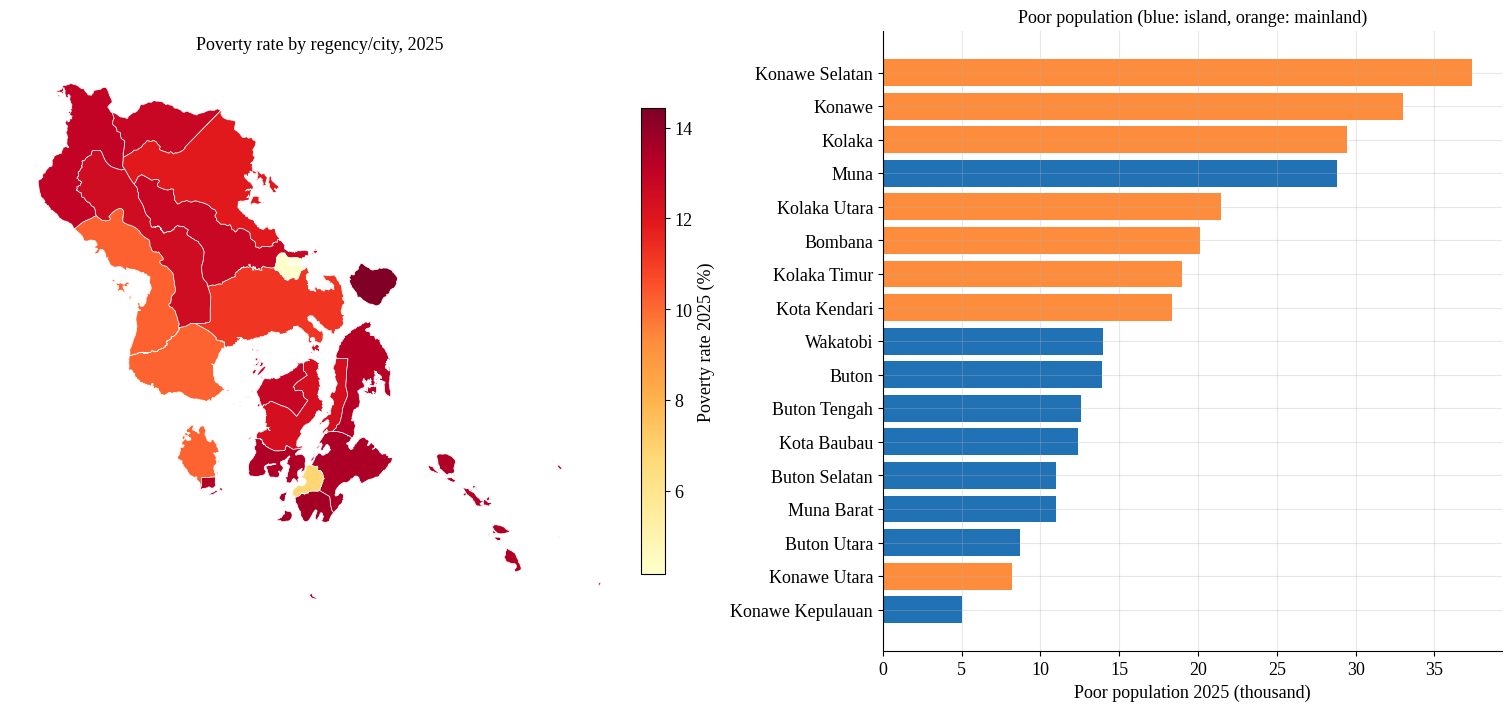

Pada 2025, persentase penduduk miskin tertinggi terdapat di Konawe Kepulauan (14,42 persen) dan terendah di Kota
Kendari (4,18 persen). Jumlah penduduk miskin terbanyak ada di Konawe Selatan (37,40 ribu), Konawe (33,04 ribu),
Kolaka (29,45 ribu). Rata-rata tertimbang penduduk untuk gugus kepulauan 12,15 persen dan gugus daratan 9,98
persen.



In [4]:
pk, spat = D['pk'], D['spat']
KAB = sorted(spat['region_code'].unique().tolist())
THN = int(pk.loc[pk['variable'] == 'poverty_rate_p0', 'year'].max())
prof = (pk[(pk['year'] == THN) & pk['region_code'].isin(KAB)]
        .pivot_table(index=['region_code', 'region_name'], columns='variable', values='value').reset_index())
p26 = D['pop'][(D['pop']['year'] == 2026) & (D['pop']['category'] == 'total') & (D['pop']['series'] == 'projection_sp2020')].set_index('region_code')['value']
prof['population_2026'] = prof['region_code'].map(p26)
prof = prof.merge(spat[['region_code', 'cluster', 'landmass']], on='region_code', how='left')
prof['code'] = prof['region_code'].astype(str).str[2:]

def gambar_peta(ax, nilai, cmap='YlOrRd', label_cb='', norma=None, vmin=None, vmax=None):
    """Peta tematik dari GeoJSON; nilai = kamus kode wilayah -> angka."""
    patches, vals = [], []
    for ft in GEO['features']:
        kode = int(ft['properties']['region_code'])
        geom = ft['geometry']
        polys = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
        for poly in polys:
            patches.append(MplPolygon(np.array(poly[0]), closed=True))
            vals.append(nilai.get(kode, np.nan))
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad('#d9d9d9')
    pc = PatchCollection(patches, cmap=cm, norm=norma, edgecolor='white', linewidth=0.5)
    pc.set_array(np.ma.masked_invalid(np.array(vals, dtype=float)))
    if norma is None:
        pc.set_clim(vmin if vmin is not None else np.nanmin(vals), vmax if vmax is not None else np.nanmax(vals))
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect('equal')
    ax.set_axis_off()
    cb = plt.colorbar(pc, ax=ax, shrink=0.75, pad=0.02)
    cb.set_label(label_cb)
    return pc

T01 = prof[['code', 'region_name', 'cluster', 'poverty_rate_p0', 'poor_population', 'poverty_gap_index_p1', 'poverty_severity_index_p2',
            'gini_ratio', 'population_2026']].copy()
if 'poverty_line' in prof:
    T01['Poverty line (IDR per capita per month)'] = prof['poverty_line'].values
T01 = T01.rename(columns={'code': 'Code', 'region_name': 'Regency/city', 'cluster': 'Cluster', 'poverty_rate_p0': f'Poverty rate {THN} (%)',
                          'poor_population': f'Poor population {THN} (thousand)', 'poverty_gap_index_p1': f'Poverty gap index P1 {THN}',
                          'poverty_severity_index_p2': f'Poverty severity index P2 {THN}', 'gini_ratio': f'Gini ratio {THN}',
                          'population_2026': 'Projected population 2026'}).sort_values(f'Poverty rate {THN} (%)', ascending=False)
simpan_tabel(T01.round(3), 'K01_poverty_profile', f'Poverty profile of regencies/cities, {THN}')
display(T01.round(2))

fig, axs = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
gambar_peta(axs[0], dict(zip(prof['region_code'], prof['poverty_rate_p0'])), 'YlOrRd', f'Poverty rate {THN} (%)')
axs[0].set_title(f'Poverty rate by regency/city, {THN}')
urut = prof.sort_values('poor_population')
axs[1].barh(urut['region_name'], urut['poor_population'], color=np.where(urut['cluster'] == 'island', '#2171b5', '#fd8d3c'))
axs[1].set_xlabel(f'Poor population {THN} (thousand)')
axs[1].set_title('Poor population (blue: island, orange: mainland)')
simpan_gambar(fig, 'K01_poverty_profile_map', f'Poverty rate and poor population by regency/city, {THN}')

tertinggi, terendah = prof.sort_values('poverty_rate_p0').iloc[-1], prof.sort_values('poverty_rate_p0').iloc[0]
terbanyak = prof.sort_values('poor_population', ascending=False).head(3)
rata = prof.groupby('cluster').apply(lambda d: np.average(d['poverty_rate_p0'], weights=d['population_2026']))
tafsir('K01', f"Pada {THN}, persentase penduduk miskin tertinggi terdapat di {tertinggi['region_name']} ({angka(tertinggi['poverty_rate_p0'])} persen) dan terendah di {terendah['region_name']} ({angka(terendah['poverty_rate_p0'])} persen). "
       f"Jumlah penduduk miskin terbanyak ada di " + ', '.join(f"{r['region_name']} ({angka(r['poor_population'])} ribu)" for _, r in terbanyak.iterrows())
       + f". Rata-rata tertimbang penduduk untuk gugus kepulauan {angka(rata.get('island', np.nan))} persen dan gugus daratan {angka(rata.get('mainland', np.nan))} persen.")

## Langkah 4. Kalibrasi distribusi dan validasi

Pengeluaran per kapita tiap wilayah didekati dengan distribusi log-normal. Posisi garis kemiskinan ditentukan oleh persentase penduduk miskin, $d_{k} = \Phi^{-1}(P0_{k})$. Untuk distribusi log-normal, indeks kedalaman (P1) dan keparahan (P2) kemiskinan memiliki bentuk tertutup:

$$P1_{k} = \Phi(d_{k}) - e^{-\sigma_{k} d_{k} + \sigma_{k}^{2}/2}\,\Phi(d_{k} - \sigma_{k})$$

$$P2_{k} = \Phi(d_{k}) - 2e^{-\sigma_{k} d_{k} + \sigma_{k}^{2}/2}\,\Phi(d_{k} - \sigma_{k}) + e^{-2\sigma_{k} d_{k} + 2\sigma_{k}^{2}}\,\Phi(d_{k} - 2\sigma_{k})$$

Kita membandingkan dua cara menetapkan sebaran $\sigma_{k}$. Cara pertama memakai rasio gini, $\sigma_{k} = \sqrt{2}\,\Phi^{-1}\{(1 + Gini_{k})/2\}$, yang menggambarkan ketimpangan seluruh distribusi. Cara kedua adalah kalibrasi lokal: $\sigma_{k}$ dipilih agar P1 dugaan sama dengan P1 resmi, sehingga bentuk distribusi di sekitar garis kemiskinan tertangkap. Kedua cara diuji di luar sampel dengan P2 resmi yang tidak dipakai dalam kalibrasi, dan cara yang lebih tepat dipakai dalam simulasi.

Karena data kemiskinan kabupaten/kota 2026 belum tersedia, persentase penduduk miskin tahun terakhir disesuaikan secara proporsional sehingga jumlah penduduk miskin seluruh kabupaten/kota dengan penduduk 2026 sama dengan angka provinsi Maret 2026. Elastisitas persentase penduduk miskin terhadap garis kemiskinan riil tiap wilayah adalah $\eta_{k} = \phi(d_{k}) / \{\sigma_{k}\Phi(d_{k})\}$.

,Code,Regency/city,Gini ratio,Sigma from Gini,Sigma calibrated to P1,Official P1 2025,P1 implied by Gini sigma,Official P2 2025,P2 implied by Gini sigma,P2 implied by P1-calibrated sigma (out of sample),Baseline poverty rate 2026 (%),Baseline poor population 2026,Poverty elasticity (P1-calibrated),Poverty elasticity (Gini-based)
0,01,Buton,0.350,0.642,0.279,1.69,3.386,0.33,1.274,0.342,12.698,15955.305,5.864,2.554
1,02,Muna,0.381,0.703,0.323,1.74,3.296,0.39,1.302,0.391,11.698,27436.971,5.198,2.388
2,03,Konawe,0.268,0.484,0.533,2.75,2.544,0.82,0.782,0.905,12.057,34120.458,3.123,3.437
3,04,Kolaka,0.286,0.518,0.398,1.65,2.057,0.40,0.644,0.424,9.613,24443.695,4.456,3.422
4,05,Konawe Selatan,0.327,0.597,0.355,1.67,2.570,0.35,0.899,0.398,10.547,35862.769,4.868,2.898
5,06,Bombana,0.338,0.618,0.450,1.82,2.357,0.43,0.834,0.513,9.566,15840.527,3.946,2.873
6,07,Wakatobi,0.316,0.576,0.434,2.46,3.093,0.69,1.081,0.703,12.642,15396.216,3.778,2.851
7,08,Kolaka Utara,0.332,0.607,0.428,2.33,3.093,0.65,1.115,0.655,12.208,18821.745,3.875,2.734
8,09,Buton Utara,0.314,0.572,0.243,1.46,3.028,0.29,1.051,0.262,12.472,8906.110,6.776,2.882
9,10,Konawe Utara,0.414,0.770,0.426,2.10,3.359,0.49,1.398,0.581,11.217,8633.778,3.987,2.207


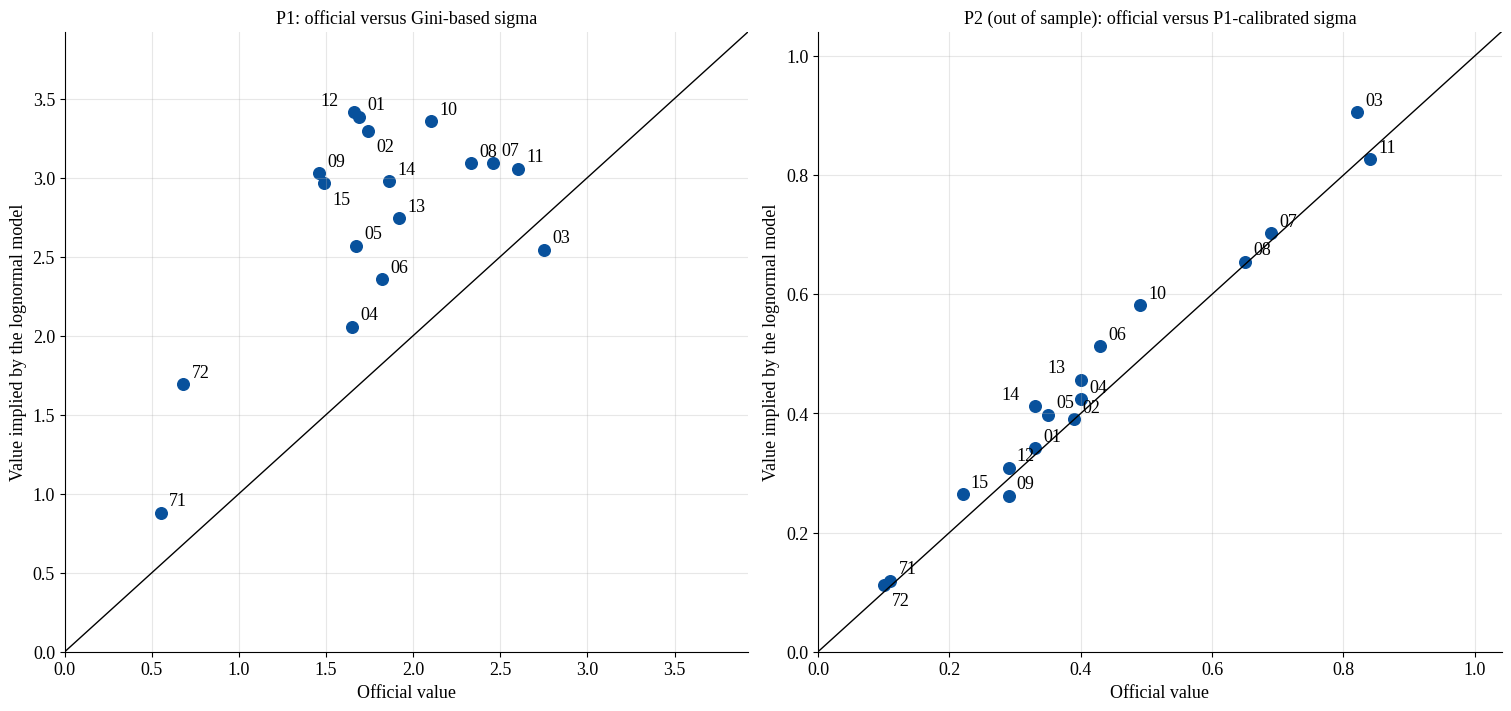

Sebaran yang diturunkan dari rasio gini menaksir P1 lebih tinggi dari angka resmi pada 16 dari 17 wilayah (rata-
rata selisih mutlak 0,970 poin, korelasi 0,621), sehingga rasio gini kurang menggambarkan bentuk distribusi di
sekitar garis kemiskinan. Kalibrasi lokal terhadap P1 berhasil pada 17 wilayah. Pada uji di luar sampel, P2 dugaan
dari kalibrasi lokal berkorelasi 0,987 dengan P2 resmi (rata-rata selisih mutlak 0,037 poin), dibanding korelasi
0,331 dan selisih 0,557 poin bila memakai rasio gini; simulasi berikutnya memakai sebaran hasil kalibrasi lokal.
Faktor penyesuaian ke 2026-03 sebesar 0,9434, sehingga jumlah penduduk miskin seluruh wilayah sama dengan angka
provinsi 293,47 ribu orang. Elastisitas kemiskinan terhadap garis kemiskinan riil berkisar 3,12 (Konawe) sampai
7,87 (Kota Baubau), lebih besar daripada versi rasio gini (2,21 sampai 3,44).



In [5]:
def p1_ln(sig, d):
    return norm.cdf(d) - np.exp(-sig * d + sig ** 2 / 2) * norm.cdf(d - sig)

def p2_ln(sig, d):
    return norm.cdf(d) - 2 * np.exp(-sig * d + sig ** 2 / 2) * norm.cdf(d - sig) + np.exp(-2 * sig * d + 2 * sig ** 2) * norm.cdf(d - 2 * sig)

prof['d_obs'] = norm.ppf(prof['poverty_rate_p0'] / 100)
prof['sigma_gini'] = np.sqrt(2) * norm.ppf((1 + prof['gini_ratio']) / 2)

def kalibrasi_p1(row):
    target = row['poverty_gap_index_p1'] / 100
    try:
        return brentq(lambda sg: p1_ln(sg, row['d_obs']) - target, 1e-3, 5.0)
    except ValueError:
        return np.nan

prof['sigma_p1'] = prof.apply(kalibrasi_p1, axis=1)
prof['P1_gini'] = p1_ln(prof['sigma_gini'], prof['d_obs']) * 100
prof['P2_gini'] = p2_ln(prof['sigma_gini'], prof['d_obs']) * 100
prof['P2_p1cal'] = p2_ln(prof['sigma_p1'], prof['d_obs']) * 100
ok_p1 = prof['sigma_p1'].notna()
prof['sigma'] = np.where(ok_p1, prof['sigma_p1'], prof['sigma_gini'])

def ringkas(pred, aktual):
    m = pred.notna() & aktual.notna()
    return np.corrcoef(pred[m], aktual[m])[0, 1], (pred[m] - aktual[m]).abs().mean()
r_p1g, e_p1g = ringkas(prof['P1_gini'], prof['poverty_gap_index_p1'])
r_p2g, e_p2g = ringkas(prof['P2_gini'], prof['poverty_severity_index_p2'])
r_p2c, e_p2c = ringkas(prof['P2_p1cal'], prof['poverty_severity_index_p2'])

pov = D['pov']
miskin_prov = pov[(pov['variable'] == 'poor_population') & (pov['area'] == 'total') & (pov['component'] == 'total')].sort_values('period')
PER_PROV, MISKIN_PROV = miskin_prov['period'].iloc[-1], float(miskin_prov['value'].iloc[-1]) * 1000
SKALA = MISKIN_PROV / (prof['poverty_rate_p0'] / 100 * prof['population_2026']).sum()
prof['p0_base'] = prof['poverty_rate_p0'] * SKALA
prof['d_base'] = norm.ppf(prof['p0_base'] / 100)
prof['poor_base'] = prof['p0_base'] / 100 * prof['population_2026']
prof['eta'] = norm.pdf(prof['d_base']) / (prof['sigma'] * norm.cdf(prof['d_base']))
prof['eta_gini'] = norm.pdf(prof['d_base']) / (prof['sigma_gini'] * norm.cdf(prof['d_base']))

T02 = prof[['code', 'region_name', 'gini_ratio', 'sigma_gini', 'sigma_p1', 'poverty_gap_index_p1', 'P1_gini', 'poverty_severity_index_p2', 'P2_gini',
            'P2_p1cal', 'p0_base', 'poor_base', 'eta', 'eta_gini']].rename(columns={
    'code': 'Code', 'region_name': 'Regency/city', 'gini_ratio': 'Gini ratio', 'sigma_gini': 'Sigma from Gini', 'sigma_p1': 'Sigma calibrated to P1',
    'poverty_gap_index_p1': f'Official P1 {THN}', 'P1_gini': 'P1 implied by Gini sigma', 'poverty_severity_index_p2': f'Official P2 {THN}',
    'P2_gini': 'P2 implied by Gini sigma', 'P2_p1cal': 'P2 implied by P1-calibrated sigma (out of sample)',
    'p0_base': f'Baseline poverty rate {PER_PROV[:4]} (%)', 'poor_base': f'Baseline poor population {PER_PROV[:4]}',
    'eta': 'Poverty elasticity (P1-calibrated)', 'eta_gini': 'Poverty elasticity (Gini-based)'})
simpan_tabel(T02.round(4), 'K02_calibration', 'Lognormal calibration and validation by regency/city')
display(T02.round(3))

fig, axs = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
for ax, xa, ya, judul in [(axs[0], prof['poverty_gap_index_p1'], prof['P1_gini'], 'P1: official versus Gini-based sigma'),
                          (axs[1], prof['poverty_severity_index_p2'], prof['P2_p1cal'], 'P2 (out of sample): official versus P1-calibrated sigma')]:
    ax.scatter(xa, ya, s=70, color='#08519c')
    lim = np.nanmax([xa.max(), ya.max()]) * 1.15
    ax.plot([0, lim], [0, lim], color='black', lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    label_titik(ax, xa.to_numpy(), ya.to_numpy(), prof['code'].to_numpy())
    ax.set_xlabel('Official value')
    ax.set_ylabel('Value implied by the lognormal model')
    ax.set_title(judul)
simpan_gambar(fig, 'K02_lognormal_validation', 'Validation of the lognormal approximation (labels: region code)')

tafsir('K02', f"Sebaran yang diturunkan dari rasio gini menaksir P1 lebih tinggi dari angka resmi pada {int((prof['P1_gini'] > prof['poverty_gap_index_p1']).sum())} dari {len(prof)} wilayah "
       f"(rata-rata selisih mutlak {angka(e_p1g, 3)} poin, korelasi {angka(r_p1g, 3)}), sehingga rasio gini kurang menggambarkan bentuk distribusi di sekitar garis kemiskinan. "
       f"Kalibrasi lokal terhadap P1 berhasil pada {int(ok_p1.sum())} wilayah. Pada uji di luar sampel, P2 dugaan dari kalibrasi lokal berkorelasi {angka(r_p2c, 3)} dengan P2 resmi "
       f"(rata-rata selisih mutlak {angka(e_p2c, 3)} poin), dibanding korelasi {angka(r_p2g, 3)} dan selisih {angka(e_p2g, 3)} poin bila memakai rasio gini; "
       f"simulasi berikutnya memakai sebaran hasil kalibrasi lokal. Faktor penyesuaian ke {PER_PROV} sebesar {angka(SKALA, 4)}, sehingga jumlah penduduk miskin seluruh wilayah sama dengan angka provinsi "
       f"{angka(MISKIN_PROV / 1000)} ribu orang. Elastisitas kemiskinan terhadap garis kemiskinan riil berkisar {angka(prof['eta'].min())} ({prof.loc[prof['eta'].idxmin(), 'region_name']}) "
       f"sampai {angka(prof['eta'].max())} ({prof.loc[prof['eta'].idxmax(), 'region_name']}), lebih besar daripada versi rasio gini ({angka(prof['eta_gini'].min())} sampai {angka(prof['eta_gini'].max())}).")

## Langkah 5. Paparan harga dan paparan pendapatan

**Paparan harga (konsumen).** Setiap kabupaten/kota dipetakan ke kota IHK acuan (Kendari, Baubau, Konawe, atau Kolaka) yang terdekat di daratan atau pulau yang sama; bila tidak ada, dipakai kota IHK terdekat. Bobot ikan segar dan makanan lain diambil dari bobot tersirat subkelompok Makanan 2022 kota acuan, dikali pangsa blok ikan segar dalam subkelompok Makanan menurut SBH 2018. Untuk Konawe dan Kolaka yang belum menjadi kota IHK pada SBH 2018, pangsa ikan memakai rata-rata Kendari dan Baubau.

**Paparan pendapatan (produsen).** Ketergantungan pada perikanan tangkap didekati dengan nilai produksi perikanan tangkap KKP 2024 dibagi PDRB atas dasar harga berlaku 2024. Nilai produksi adalah output bruto, sehingga ukuran ini dibaca sebagai indikator relatif antarwilayah.

,Code,Regency/city,Reference CPI region,Distance to reference (km),Sea crossing to reference,Fresh fish weight in CPI (%),Other food weight in CPI (%),"Capture fisheries output, share of GRDP 2024 (%)",Construction cost index (latest),IKK year
14,15,Buton Selatan,Kota Baubau,19.22,No,7.26,16.16,20.63,98.80,2024
13,14,Buton Tengah,Kota Baubau,37.83,Yes,7.26,16.16,16.16,103.09,2024
12,13,Muna Barat,Kota Baubau,72.83,Yes,7.26,16.16,11.92,91.91,2024
11,12,Konawe Kepulauan,Kota Kendari,64.39,Yes,6.15,17.03,9.87,95.91,2024
5,06,Bombana,Kolaka,59.82,No,8.00,19.81,9.53,94.69,2024
6,07,Wakatobi,Kota Baubau,98.44,Yes,7.26,16.16,8.78,109.48,2024
0,01,Buton,Kota Baubau,28.56,No,7.26,16.16,7.27,99.31,2024
1,02,Muna,Kota Baubau,55.74,Yes,7.26,16.16,7.16,91.80,2024
9,10,Konawe Utara,Konawe,49.27,No,9.64,23.86,6.85,95.66,2024
8,09,Buton Utara,Kota Baubau,79.86,No,7.26,16.16,4.88,99.85,2024


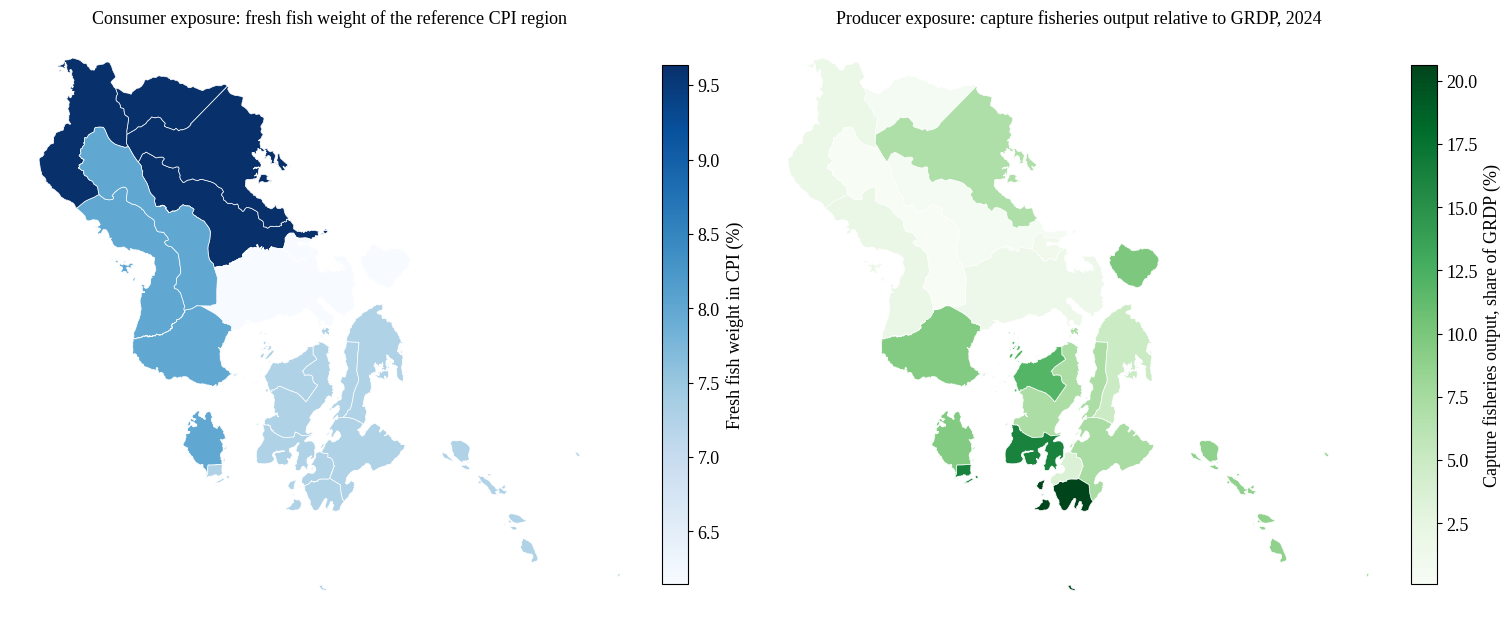

Pemetaan kota IHK acuan menghasilkan 8 wilayah berpatokan ke Kota Baubau, 3 ke Kota Kendari, 3 ke Kabupaten Konawe,
dan 3 ke Kabupaten Kolaka. Bobot ikan segar dalam IHK kota acuan berkisar 6,15 sampai 9,64 persen. Ketergantungan
pada perikanan tangkap tertinggi terdapat di Buton Selatan (20,6 persen dari PDRB), Buton Tengah (16,2 persen dari
PDRB), Muna Barat (11,9 persen dari PDRB), sedangkan terendah di Kolaka Timur (0,11 persen).



In [6]:
pairs = D['pairs']
CPI_REG = [7471, 7472, 7403, 7404]
REF = {}
for k in KAB:
    if k in CPI_REG:
        REF[k] = k
        continue
    c = pairs[(pairs['region_code_from'] == k) & pairs['region_code_to'].isin(CPI_REG)]
    sama = c[c['same_landmass'] == 1]
    REF[k] = int((sama if len(sama) else c).sort_values('distance_km').iloc[0]['region_code_to'])
w22, bmc = D['w22'], D['bmc']
W011 = w22[(w22['level'] == 2) & (w22['coicop_code'] == '011')].set_index('region_code')['weight_in_general']
tot011 = bmc.groupby('region_code')['weight_in_general_pct'].sum()
pangsa_ikan = (bmc[bmc['block_code'] == '01.1.103'].set_index('region_code')['weight_in_general_pct'] / tot011).dropna()
PANGSA_IKAN = {j: float(pangsa_ikan.get(j, pangsa_ikan.mean())) for j in CPI_REG}
WF = {j: PANGSA_IKAN[j] * float(W011[j]) for j in CPI_REG}
WR = {j: float(W011[j]) - WF[j] for j in CPI_REG}
nama_reg = spat.set_index('region_code')['region_name'].to_dict()

grdp = D['grdp']
g24 = grdp[(grdp['variable'] == 'grdp_current_price') & (grdp['year'] == 2024) & grdp['region_code'].isin(KAB)]
satuan = str(g24['unit'].iloc[0]).lower()
ke_juta = 1000.0 if 'miliar' in satuan else 1.0
nilai_kkp = D['kkpk'].set_index('region_code')['value_million_rp']
FSH = (nilai_kkp / (g24.set_index('region_code')['value'] * ke_juta)).reindex(KAB).fillna(0.0)
ikk = D['ikk'].dropna(subset=['ikk']).sort_values('year').groupby('region_code').last()
jarak_ref = {k: (0.0 if REF[k] == k else float(pairs[(pairs['region_code_from'] == k) & (pairs['region_code_to'] == REF[k])]['distance_km'].iloc[0])) for k in KAB}
laut_ref = {k: (0 if REF[k] == k else int(pairs[(pairs['region_code_from'] == k) & (pairs['region_code_to'] == REF[k])]['cross_sea'].iloc[0])) for k in KAB}

prof['ref'] = prof['region_code'].map(REF)
prof['w_fish'] = prof['ref'].map(WF)
prof['w_rest'] = prof['ref'].map(WR)
prof['fsh'] = prof['region_code'].map(FSH)
T03 = pd.DataFrame({'Code': prof['code'], 'Regency/city': prof['region_name'], 'Reference CPI region': prof['ref'].map(nama_reg),
                    'Distance to reference (km)': prof['region_code'].map(jarak_ref), 'Sea crossing to reference': prof['region_code'].map(laut_ref).map({0: 'No', 1: 'Yes'}),
                    'Fresh fish weight in CPI (%)': prof['w_fish'] * 100, 'Other food weight in CPI (%)': prof['w_rest'] * 100,
                    'Capture fisheries output, share of GRDP 2024 (%)': prof['fsh'] * 100,
                    'Construction cost index (latest)': prof['region_code'].map(ikk['ikk']),
                    'IKK year': prof['region_code'].map(ikk['year'])}).sort_values('Capture fisheries output, share of GRDP 2024 (%)', ascending=False)
simpan_tabel(T03.round(3), 'K03_exposure', 'Consumer price exposure and fisheries income exposure by regency/city')
display(T03.round(2))

fig, axs = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
gambar_peta(axs[0], dict(zip(prof['region_code'], prof['w_fish'] * 100)), 'Blues', 'Fresh fish weight in CPI (%)')
axs[0].set_title('Consumer exposure: fresh fish weight of the reference CPI region')
gambar_peta(axs[1], dict(zip(prof['region_code'], prof['fsh'] * 100)), 'Greens', 'Capture fisheries output, share of GRDP (%)')
axs[1].set_title('Producer exposure: capture fisheries output relative to GRDP, 2024')
simpan_gambar(fig, 'K03_exposure_maps', 'Consumer and producer exposure by regency/city')

atas3 = prof.sort_values('fsh', ascending=False).head(3)
tafsir('K03', f"Pemetaan kota IHK acuan menghasilkan {sum(1 for k in KAB if REF[k] == 7472)} wilayah berpatokan ke Kota Baubau, {sum(1 for k in KAB if REF[k] == 7471)} ke Kota Kendari, "
       f"{sum(1 for k in KAB if REF[k] == 7403)} ke Kabupaten Konawe, dan {sum(1 for k in KAB if REF[k] == 7404)} ke Kabupaten Kolaka. "
       f"Bobot ikan segar dalam IHK kota acuan berkisar {angka(prof['w_fish'].min() * 100)} sampai {angka(prof['w_fish'].max() * 100)} persen. "
       f"Ketergantungan pada perikanan tangkap tertinggi terdapat di " + ', '.join(f"{r['region_name']} ({angka(r['fsh'] * 100, 1)} persen dari PDRB)" for _, r in atas3.iterrows())
       + f", sedangkan terendah di {prof.sort_values('fsh').iloc[0]['region_name']} ({angka(prof['fsh'].min() * 100, 2)} persen).")

## Langkah 6. Menurunkan simulasi ke kabupaten/kota

Model sistem dinamis dari notebook pertama dijalankan ulang dengan parameter yang sama sampai bulan sasaran, lalu hasilnya dicocokkan dengan tabel skenario notebook pertama. Untuk setiap kabupaten/kota $k$:

$$\frac{GK_{k}}{GK^{b}_{k}} = s_{f}\,\frac{w^{ikan}_{k} c_{T} + w^{lain}_{k} r_{T}}{w^{ikan}_{k} + w^{lain}_{k}} + (1 - s_{f}), \qquad \frac{Y_{k}}{Y^{b}_{k}} = 1 + \beta\, F_{k}\,(p_{T} K_{T} - 1)$$

$$P0_{k} = \Phi\!\left(d_{k} + \frac{\ln(GK_{k}/GK^{b}_{k}) - \ln(Y_{k}/Y^{b}_{k})}{\sigma_{k}}\right), \qquad \Delta M_{k} = \frac{P0_{k} - P0^{b}_{k}}{100}\, N_{k}$$

dengan $c_{T}$ rasio harga ikan konsumen, $r_{T}$ rasio harga makanan lain, $p_{T}$ rasio harga produsen, $K_{T}$ rasio kapasitas tangkap, $F_{k}$ ketergantungan pada perikanan tangkap, $\beta$ daya terus penerimaan perikanan ke pendapatan rumah tangga (nilai dasar 1, diuji 0,5 sampai 1,5), dan $N_{k}$ penduduk 2026. Hasil dilaporkan untuk saluran konsumen saja dan untuk gabungan saluran konsumen dan produsen.

Selisih maksimum replikasi terhadap notebook pertama (poin persen): 1.7340127152820628e-05


,Scenario,"Change in poor population, consumer channel","Change in poor population, both channels",Consumer channel with Gini-based sigma,"Province-level result, notebook 1"
0,C Compromise (Pareto),-21018.0,-30834.0,-12976.0,NaN
1,S0 Baseline,0.0,0.0,0.0,0.0
2,S1 Logistics and cold chain,-5138.0,-9818.0,-3126.0,-2770.0
3,S2 Market operation,-12113.0,-6863.0,-7400.0,-6561.0
4,S3 Demand absorption,21175.0,11858.0,12696.0,11232.0
5,S4 Logistics plus absorption,16783.0,2491.0,10086.0,8926.0
6,S5 Combined with food supply management,9216.0,-4796.0,5522.0,4806.0


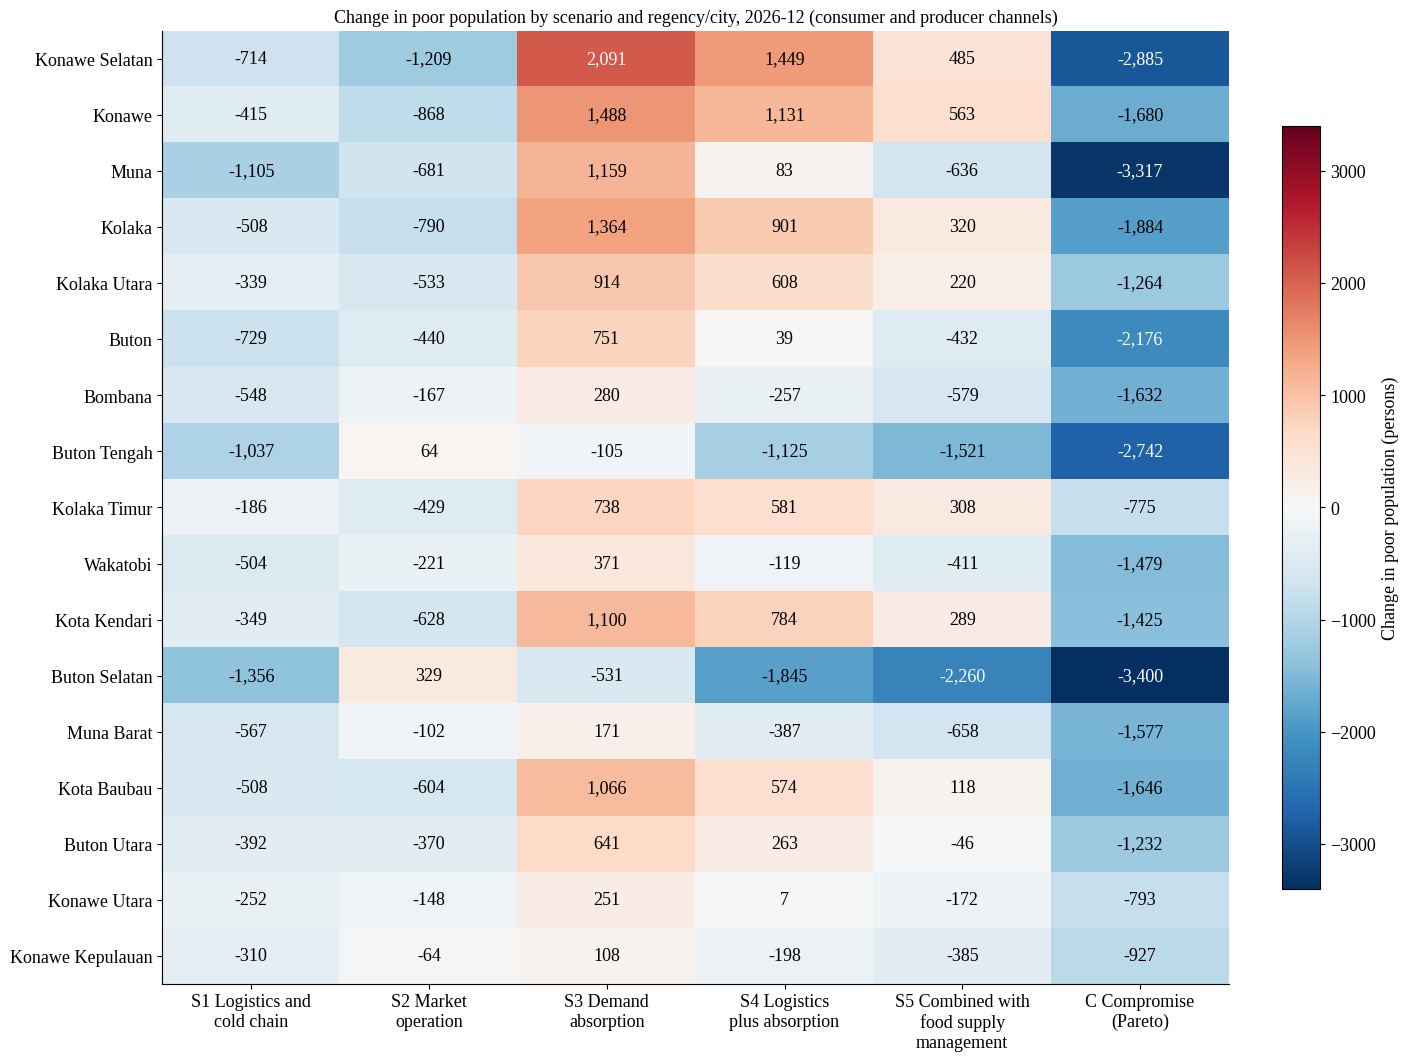

Replikasi model provinsi berselisih paling besar 0,000017 poin persen dari notebook pertama, sehingga keadaan pada
2026-12 identik. Pada skenario S2 (operasi pasar), jumlah penduduk miskin seluruh kabupaten/kota berkurang 12.113
orang melalui saluran konsumen saja, dan berkurang 6.863 orang bila saluran produsen ikut dihitung; 2 dari 17
wilayah mencatat kenaikan. Pada skenario S3 (penyerapan permintaan), jumlah penduduk miskin seluruh kabupaten/kota
bertambah 21.175 orang melalui saluran konsumen saja, dan bertambah 11.858 orang bila saluran produsen ikut
dihitung; 15 dari 17 wilayah mencatat kenaikan. Pada skenario kompromi Pareto, jumlah penduduk miskin seluruh
kabupaten/kota berkurang 21.018 orang melalui saluran konsumen saja, dan berkurang 30.834 orang bila saluran
produsen ikut dihitung; 0 dari 17 wilayah mencatat kenaikan. Untuk skenario S2, jumlah dampak saluran konsumen
seluruh wilayah -12.113 orang dengan sebaran hasil kalibrasi lokal, -7.400 orang dengan sebaran rasio gini, 

In [7]:
last_cpi = D['cpi'].loc[D['cpi']['region_code'] == 7400, 'period'].max()
H = (pd.Period(TARGET_BULAN, freq='M') - pd.Period(last_cpi, freq='M')).n

def sd_akhir(tuas, prm, H=H):
    """Replikasi model sistem dinamis notebook pertama; mengembalikan keadaan pada bulan sasaran."""
    p_, K_, keadaan = 1.0, 1.0, None
    for h in range(H):
        ramp = min(1.0, (h + 1) / prm['ramp'])
        f_, a_, s_ = tuas['f'] * ramp, tuas['a'] * ramp, tuas['s'] * ramp
        r_ = np.exp(-tuas['g'] * (h + 1))
        c_ = (1 - prm['m0']) * p_ + prm['m0'] * (1 - f_)
        cpi_r = 1 + prm['w_fish'] * (c_ - 1) + prm['w_rest'] * (r_ - 1)
        ntn = p_ ** prm['theta'] / cpi_r ** prm['psi']
        d_ = c_ ** prm['eps_d'] * (1 + a_)
        q_ = K_ + s_
        keadaan = {'c': c_, 'p': p_, 'K': K_, 'r': r_, 'ntn': ntn, 'cpi_r': cpi_r}
        K_ = K_ + (ntn ** prm['eps_s'] - K_) / prm['tau']
        p_ = p_ * np.exp(prm['phi'] * (d_ - q_))
    return keadaan

SKENARIO = {
    'S0 Baseline': {'f': 0.0, 's': 0.0, 'a': 0.0, 'g': 0.0},
    'S1 Logistics and cold chain': {'f': 0.15, 's': 0.0, 'a': 0.0, 'g': 0.0},
    'S2 Market operation': {'f': 0.0, 's': 0.05, 'a': 0.0, 'g': 0.0},
    'S3 Demand absorption': {'f': 0.0, 's': 0.0, 'a': 0.08, 'g': 0.0},
    'S4 Logistics plus absorption': {'f': 0.15, 's': 0.0, 'a': 0.08, 'g': 0.0},
    'S5 Combined with food supply management': {'f': 0.15, 's': 0.0, 'a': 0.08, 'g': 0.002},
    'C Compromise (Pareto)': dict(TUAS_KOMPROMI)}
KEADAAN = {n_: sd_akhir(t_, PARAM) for n_, t_ in SKENARIO.items()}

cek = []
for _, r in T20_NB1.iterrows():
    st = KEADAAN[r['Scenario']]
    food_r = (PARAM['w_fish'] * st['c'] + PARAM['w_rest'] * st['r']) / (PARAM['w_fish'] + PARAM['w_rest'])
    p0 = norm.cdf(PARAM['z0'] + np.log(PARAM['s_f'] * food_r + 1 - PARAM['s_f']) / PARAM['sigma']) * 100
    cek.append(abs(p0 - r['Poverty rate (%)']))
print('Selisih maksimum replikasi terhadap notebook pertama (poin persen):', max(cek))

def dampak(st, df, prm, beta=1.0, produsen=True, sigma=None, fish_mult=1.0):
    wf = df['w_fish'].to_numpy() * fish_mult
    wr = (df['w_fish'] + df['w_rest']).to_numpy() - wf
    food_r = (wf * st['c'] + wr * st['r']) / (wf + wr)
    gk_r = prm['s_f'] * food_r + (1 - prm['s_f'])
    inc_r = 1 + beta * df['fsh'].to_numpy() * (st['p'] * st['K'] - 1) if produsen else np.ones(len(df))
    sig = df['sigma'].to_numpy() if sigma is None else sigma
    p0 = norm.cdf(df['d_base'].to_numpy() + (np.log(gk_r) - np.log(inc_r)) / sig) * 100
    return p0 - df['p0_base'].to_numpy(), (p0 - df['p0_base'].to_numpy()) / 100 * df['population_2026'].to_numpy()

baris = []
for n_, st in KEADAAN.items():
    dk, mk = dampak(st, prof, PARAM, produsen=False)
    dg, mg = dampak(st, prof, PARAM, produsen=True)
    for i, r in prof.reset_index(drop=True).iterrows():
        baris.append({'Scenario': n_, 'Code': r['code'], 'Regency/city': r['region_name'],
                      'Change in poverty rate, consumer channel (pp)': dk[i], 'Change in poor population, consumer channel': mk[i],
                      'Change in poverty rate, both channels (pp)': dg[i], 'Change in poor population, both channels': mg[i]})
K04 = pd.DataFrame(baris)
simpan_tabel(K04.round(4), 'K04_scenario_effects_by_region', f'Scenario effects on poverty by regency/city, {TARGET_BULAN}')

jumlah = K04.groupby('Scenario')[['Change in poor population, consumer channel', 'Change in poor population, both channels']].sum()
nb1 = T20_NB1.set_index('Scenario')['Change in poor population (thousand)'] * 1000
K05 = jumlah.reset_index()
K05['Consumer channel with Gini-based sigma'] = [dampak(KEADAAN[n_], prof, PARAM, produsen=False, sigma=prof['sigma_gini'].to_numpy())[1].sum() for n_ in K05['Scenario']]
K05['Province-level result, notebook 1'] = K05['Scenario'].map(nb1)
simpan_tabel(K05.round(1), 'K05_aggregation_check', 'Sum of regency/city effects versus the province-level result')
display(K05.round(0))

piv = K04.pivot_table(index='Regency/city', columns='Scenario', values='Change in poor population, both channels')
piv = piv[[c for c in SKENARIO if c in piv.columns and not c.startswith('S0')]]
piv = piv.loc[prof.sort_values('poor_base', ascending=False)['region_name']]
fig, ax = plt.subplots(figsize=(14, 10.5), constrained_layout=True)
batas = np.nanmax(np.abs(piv.to_numpy()))
im = ax.imshow(piv.to_numpy(), cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-batas, vcenter=0, vmax=batas), aspect='auto')
ax.set_xticks(range(piv.shape[1]))
ax.set_xticklabels([textwrap.fill(c, 16) for c in piv.columns])
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels(piv.index)
ax.grid(False)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.iat[i, j]
        ax.text(j, i, f'{v:,.0f}', ha='center', va='center', fontsize=13, color='white' if abs(v) > 0.6 * batas else 'black')
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label('Change in poor population (persons)')
ax.set_title(f'Change in poor population by scenario and regency/city, {TARGET_BULAN} (consumer and producer channels)')
simpan_gambar(fig, 'K04_scenario_heatmap', 'Change in poor population by scenario and regency/city')

kal = [f"Replikasi model provinsi berselisih paling besar {angka(max(cek), 6)} poin persen dari notebook pertama, sehingga keadaan pada {TARGET_BULAN} identik."]
for sk in ['S2 Market operation', 'S3 Demand absorption', 'C Compromise (Pareto)']:
    x = K04[K04['Scenario'] == sk]
    kons, gab = x['Change in poor population, consumer channel'].sum(), x['Change in poor population, both channels'].sum()
    naik = x[x['Change in poor population, both channels'] > 0]
    kal.append(f"Pada skenario {SKEN_ID.get(sk, sk)}, jumlah penduduk miskin seluruh kabupaten/kota {arah(kons)} melalui saluran konsumen saja, dan {arah(gab)} bila saluran produsen ikut dihitung; "
               f"{len(naik)} dari {len(x)} wilayah mencatat kenaikan.")
bd = K05.set_index('Scenario')
kal.append(f"Untuk skenario S2, jumlah dampak saluran konsumen seluruh wilayah {angka(bd.loc['S2 Market operation', 'Change in poor population, consumer channel'], 0)} orang dengan sebaran hasil kalibrasi lokal, "
           f"{angka(bd.loc['S2 Market operation', 'Consumer channel with Gini-based sigma'], 0)} orang dengan sebaran rasio gini, dan {angka(bd.loc['S2 Market operation', 'Province-level result, notebook 1'], 0)} orang pada perhitungan provinsi notebook pertama. "
           f"Selisih ini berasal dari cara menetapkan sebaran pengeluaran dan dari bobot pangan yang berbeda antarwilayah; angka provinsi pada notebook pertama perlu dibaca sebagai batas bawah besaran dampak.")
tafsir('K04', ' '.join(kal))

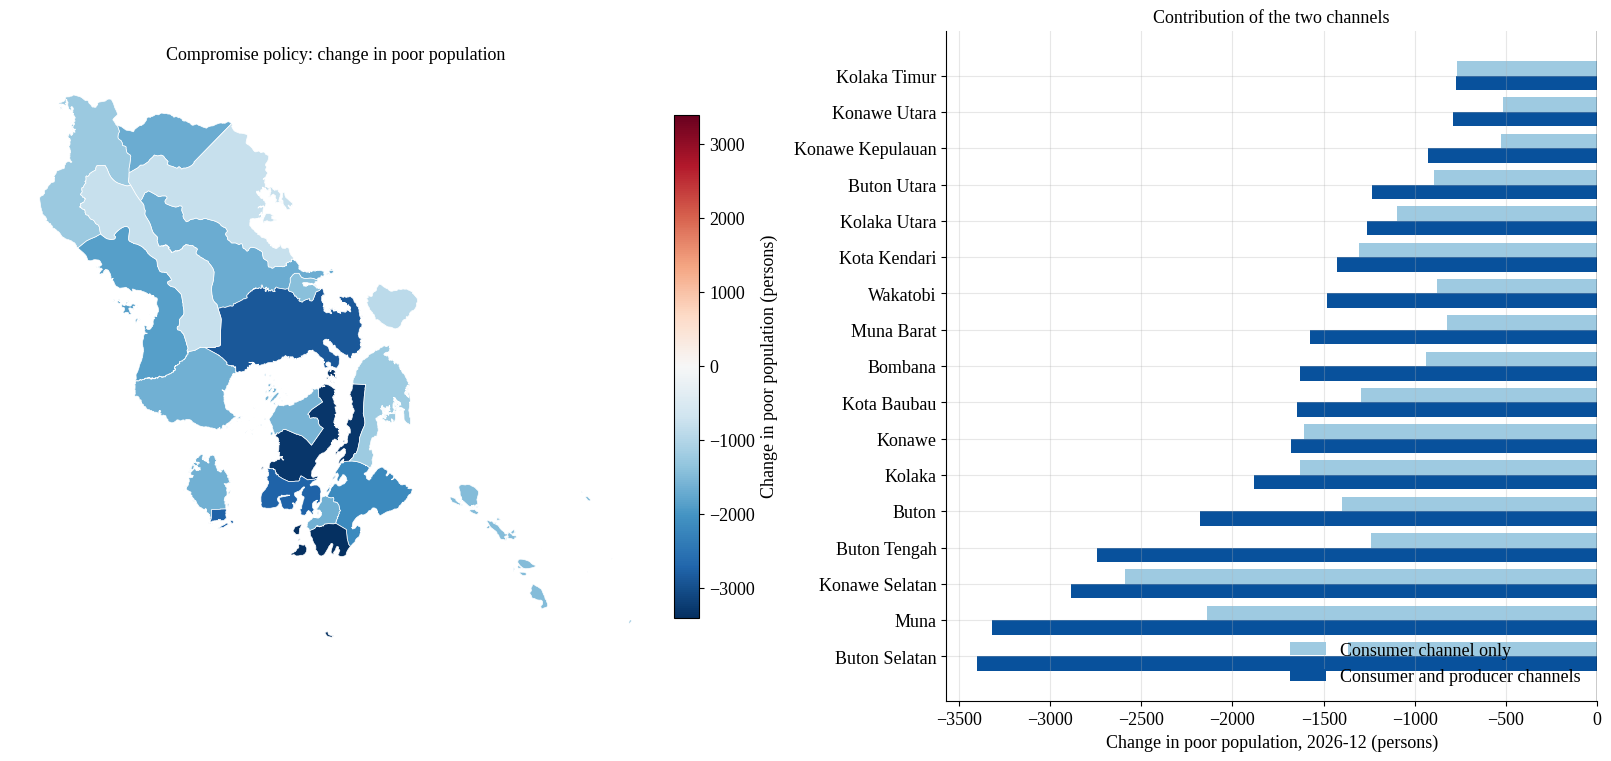

Dengan kebijakan kompromi, penurunan jumlah penduduk miskin terbesar terjadi di Buton Selatan (3.400 orang), Muna
(3.317 orang), Konawe Selatan (2.885 orang). Total seluruh wilayah berkurang 30.834 orang. Saluran produsen
menambah penurunan kemiskinan di wilayah yang bergantung pada perikanan tangkap karena penerimaan nelayan pada
skenario ini naik 12,49 persen terhadap lintasan dasar.



In [8]:
x = K04[K04['Scenario'] == 'C Compromise (Pareto)'].merge(prof[['code', 'region_code']], left_on='Code', right_on='code')
fig, axs = plt.subplots(1, 2, figsize=(16, 7.5), constrained_layout=True)
vals = dict(zip(x['region_code'], x['Change in poor population, both channels']))
b_ = max(abs(min(vals.values())), abs(max(vals.values())), 1e-9)
gambar_peta(axs[0], vals, 'RdBu_r', 'Change in poor population (persons)', norma=TwoSlopeNorm(vmin=-b_, vcenter=0, vmax=b_))
axs[0].set_title('Compromise policy: change in poor population')
xs = x.sort_values('Change in poor population, both channels')
yy = np.arange(len(xs))
axs[1].barh(yy + 0.2, xs['Change in poor population, consumer channel'], height=0.4, color='#9ecae1', label='Consumer channel only')
axs[1].barh(yy - 0.2, xs['Change in poor population, both channels'], height=0.4, color='#08519c', label='Consumer and producer channels')
axs[1].set_yticks(yy)
axs[1].set_yticklabels(xs['Regency/city'])
axs[1].axvline(0, color='black', lw=1)
axs[1].set_xlabel(f'Change in poor population, {TARGET_BULAN} (persons)')
axs[1].legend(loc='lower right', frameon=False)
axs[1].set_title('Contribution of the two channels')
simpan_gambar(fig, 'K05_compromise_effects', 'Poverty effects of the compromise policy by regency/city')

turun = xs.head(3)
tafsir('K05', f"Dengan kebijakan kompromi, penurunan jumlah penduduk miskin terbesar terjadi di " + ', '.join(f"{r['Regency/city']} ({angka(abs(r['Change in poor population, both channels']), 0)} orang)" for _, r in turun.iterrows())
       + f". Total seluruh wilayah {arah(xs['Change in poor population, both channels'].sum())}. "
       f"Saluran produsen menambah penurunan kemiskinan di wilayah yang bergantung pada perikanan tangkap karena penerimaan nelayan pada skenario ini "
       f"{'naik' if KEADAAN['C Compromise (Pareto)']['p'] * KEADAAN['C Compromise (Pareto)']['K'] > 1 else 'turun'} {angka(abs(KEADAAN['C Compromise (Pareto)']['p'] * KEADAAN['C Compromise (Pareto)']['K'] - 1) * 100)} persen terhadap lintasan dasar.")

## Langkah 7. Ketidakpastian

Kita mengacak parameter model sistem dinamis dengan rentang yang sama seperti notebook pertama, daya terus penerimaan perikanan $\beta$ (0,5 sampai 1,5), sebaran pengeluaran tiap wilayah (faktor log-normal dengan simpangan baku 0,1 di sekitar hasil kalibrasi), dan bobot ikan segar (faktor 0,8 sampai 1,2), sebanyak 500 kali. Untuk tiap wilayah dan skenario kita melaporkan persentil 5, median, dan persentil 95 perubahan jumlah penduduk miskin (kedua saluran).

,Scenario,Code,Regency/city,P5,Median,P95,Share of draws with a decrease (%)
36,C Compromise (Pareto),01,Buton,-3149.1,-2183.7,-1522.1,100.0
37,C Compromise (Pareto),02,Muna,-4658.4,-3293.3,-2256.9,100.0
38,C Compromise (Pareto),03,Konawe,-2619.4,-1695.0,-1051.1,100.0
39,C Compromise (Pareto),04,Kolaka,-2981.0,-1891.8,-1255.6,100.0
40,C Compromise (Pareto),05,Konawe Selatan,-4453.8,-2885.9,-1958.7,100.0
41,C Compromise (Pareto),06,Bombana,-2288.2,-1624.1,-1092.0,100.0
42,C Compromise (Pareto),07,Wakatobi,-2090.6,-1503.8,-987.7,100.0
43,C Compromise (Pareto),08,Kolaka Utara,-1926.7,-1266.1,-843.6,100.0
44,C Compromise (Pareto),09,Buton Utara,-1774.2,-1236.9,-843.4,100.0
45,C Compromise (Pareto),10,Konawe Utara,-1111.2,-780.7,-541.4,100.0


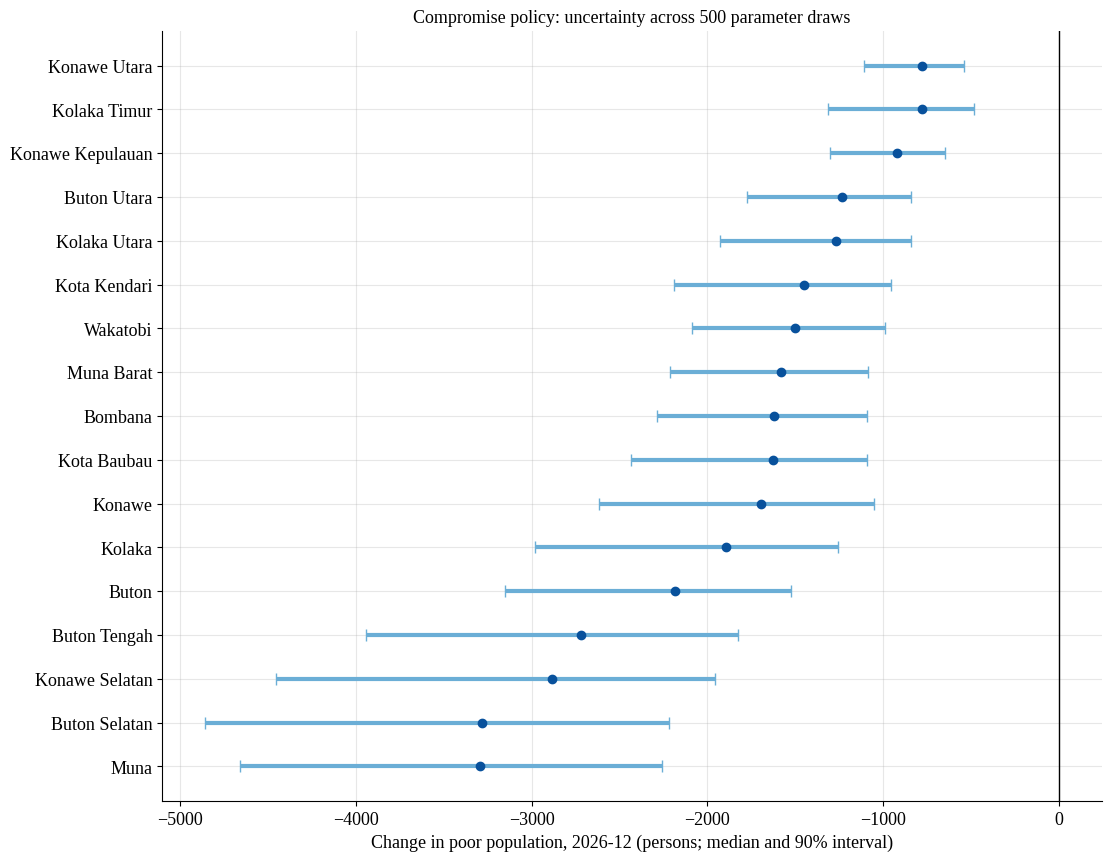

Pada 500 kali pengacakan, kebijakan kompromi mengubah jumlah penduduk miskin seluruh wilayah dengan median -30.745
orang (interval 90 persen -42.077 sampai -21.989 orang), dan 100,0 persen hasil pengacakan menunjukkan penurunan.
Penurunan yang konsisten (paling sedikit 90 persen pengacakan) terjadi di 17 wilayah: Muna, Buton Selatan, Konawe
Selatan, Buton Tengah, Buton, Kolaka, Konawe, Kota Baubau, Bombana, Muna Barat, Wakatobi, Kota Kendari, Kolaka
Utara, Buton Utara, Konawe Kepulauan, Kolaka Timur, Konawe Utara.



In [9]:
N_MC = 500
SK_UJI = ['S2 Market operation', 'S3 Demand absorption', 'C Compromise (Pareto)']
hasil = {sk: [] for sk in SK_UJI}
for _ in range(N_MC):
    prm = dict(PARAM)
    prm['eps_d'] = RNG.uniform(-1.2, -0.4)
    prm['eps_s'] = RNG.uniform(0.1, 0.6)
    prm['tau'] = RNG.uniform(3, 12)
    prm['phi'] = RNG.uniform(0.3, 1.0)
    prm['m0'] = RNG.uniform(0.25, 0.45)
    beta = RNG.uniform(0.5, 1.5)
    sig_ = prof['sigma'].to_numpy() * np.exp(RNG.normal(0, 0.1, len(prof)))
    fm = RNG.uniform(0.8, 1.2)
    for sk in SK_UJI:
        _, m_ = dampak(sd_akhir(SKENARIO[sk], prm), prof, prm, beta=beta, produsen=True, sigma=sig_, fish_mult=fm)
        hasil[sk].append(m_)
baris = []
for sk in SK_UJI:
    arr = np.array(hasil[sk])
    for i, r in prof.reset_index(drop=True).iterrows():
        v = arr[:, i]
        baris.append({'Scenario': sk, 'Code': r['code'], 'Regency/city': r['region_name'], 'P5': np.percentile(v, 5), 'Median': np.median(v),
                      'P95': np.percentile(v, 95), 'Share of draws with a decrease (%)': (v < 0).mean() * 100})
    tot = arr.sum(axis=1)
    baris.append({'Scenario': sk, 'Code': '', 'Regency/city': 'All regencies/cities', 'P5': np.percentile(tot, 5), 'Median': np.median(tot),
                  'P95': np.percentile(tot, 95), 'Share of draws with a decrease (%)': (tot < 0).mean() * 100})
K06 = pd.DataFrame(baris)
simpan_tabel(K06.round(2), 'K06_uncertainty', 'Uncertainty of poverty effects by regency/city (persons)')
display(K06[K06['Scenario'] == 'C Compromise (Pareto)'].round(1))

u = K06[(K06['Scenario'] == 'C Compromise (Pareto)') & (K06['Code'] != '')].sort_values('Median')
fig, ax = plt.subplots(figsize=(11, 8.5), constrained_layout=True)
yy = np.arange(len(u))
ax.errorbar(u['Median'], yy, xerr=[u['Median'] - u['P5'], u['P95'] - u['Median']], fmt='o', color='#08519c', ecolor='#6baed6', elinewidth=3, capsize=4)
ax.set_yticks(yy)
ax.set_yticklabels(u['Regency/city'])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(f'Change in poor population, {TARGET_BULAN} (persons; median and 90% interval)')
ax.set_title(f'Compromise policy: uncertainty across {N_MC} parameter draws')
simpan_gambar(fig, 'K06_uncertainty', 'Uncertainty of poverty effects under the compromise policy')

tot_c = K06[(K06['Scenario'] == 'C Compromise (Pareto)') & (K06['Code'] == '')].iloc[0]
kokoh = u[u['Share of draws with a decrease (%)'] >= 90]
tafsir('K06', f"Pada {N_MC} kali pengacakan, kebijakan kompromi mengubah jumlah penduduk miskin seluruh wilayah dengan median {angka(tot_c['Median'], 0)} orang "
       f"(interval 90 persen {angka(tot_c['P5'], 0)} sampai {angka(tot_c['P95'], 0)} orang), dan {angka(tot_c['Share of draws with a decrease (%)'], 1)} persen hasil pengacakan menunjukkan penurunan. "
       f"Penurunan yang konsisten (paling sedikit 90 persen pengacakan) terjadi di {len(kokoh)} wilayah"
       + (': ' + ', '.join(kokoh['Regency/city']) if len(kokoh) else '') + ".")

## Langkah 8. Tipologi prioritas wilayah

Kepekaan setiap wilayah dihitung dengan dua guncangan kecil yang terpisah: kenaikan harga ikan konsumen 1 persen (saluran konsumen) dan kenaikan penerimaan nelayan 1 persen (saluran produsen). Hasilnya dinyatakan dalam jumlah orang. Wilayah dikelompokkan menurut median kedua kepekaan untuk menentukan instrumen yang paling sesuai:

1. Kepekaan konsumen tinggi dan produsen tinggi: stabilisasi harga konsumen sekaligus dukungan penerimaan nelayan.
2. Kepekaan konsumen tinggi saja: stabilisasi harga konsumen melalui logistik dan operasi pasar.
3. Kepekaan produsen tinggi saja: dukungan penerimaan nelayan melalui penyerapan permintaan, rantai dingin, dan pengolahan.
4. Keduanya rendah: pemantauan.

,Code,Regency/city,Cluster,Baseline poor population 2026,Additional poor per 1% rise in fish consumer price,Poor lifted per 1% rise in fisher revenue,Typology,Suggested instrument
1,02,Muna,island,27436.97,330.70,102.00,Both high,Stabilise consumer prices and support fisher i...
0,01,Buton,island,15955.30,217.07,67.88,Both high,Stabilise consumer prices and support fisher i...
13,14,Buton Tengah,island,15793.16,191.75,133.17,Both high,Stabilise consumer prices and support fisher i...
14,15,Buton Selatan,island,13434.22,213.46,188.60,Both high,Stabilise consumer prices and support fisher i...
16,72,Kota Baubau,island,11158.76,204.34,31.57,Both high,Stabilise consumer prices and support fisher i...
7,08,Kolaka Utara,mainland,18821.74,156.71,14.11,Both low,Monitoring
10,11,Kolaka Timur,mainland,15539.49,109.55,0.56,Both low,Monitoring
8,09,Buton Utara,island,8906.11,140.11,29.41,Both low,Monitoring
9,10,Konawe Utara,mainland,8633.78,73.95,23.56,Both low,Monitoring
4,05,Konawe Selatan,mainland,35862.77,346.07,25.06,Consumer-sensitive,"Consumer price stabilisation (logistics, marke..."


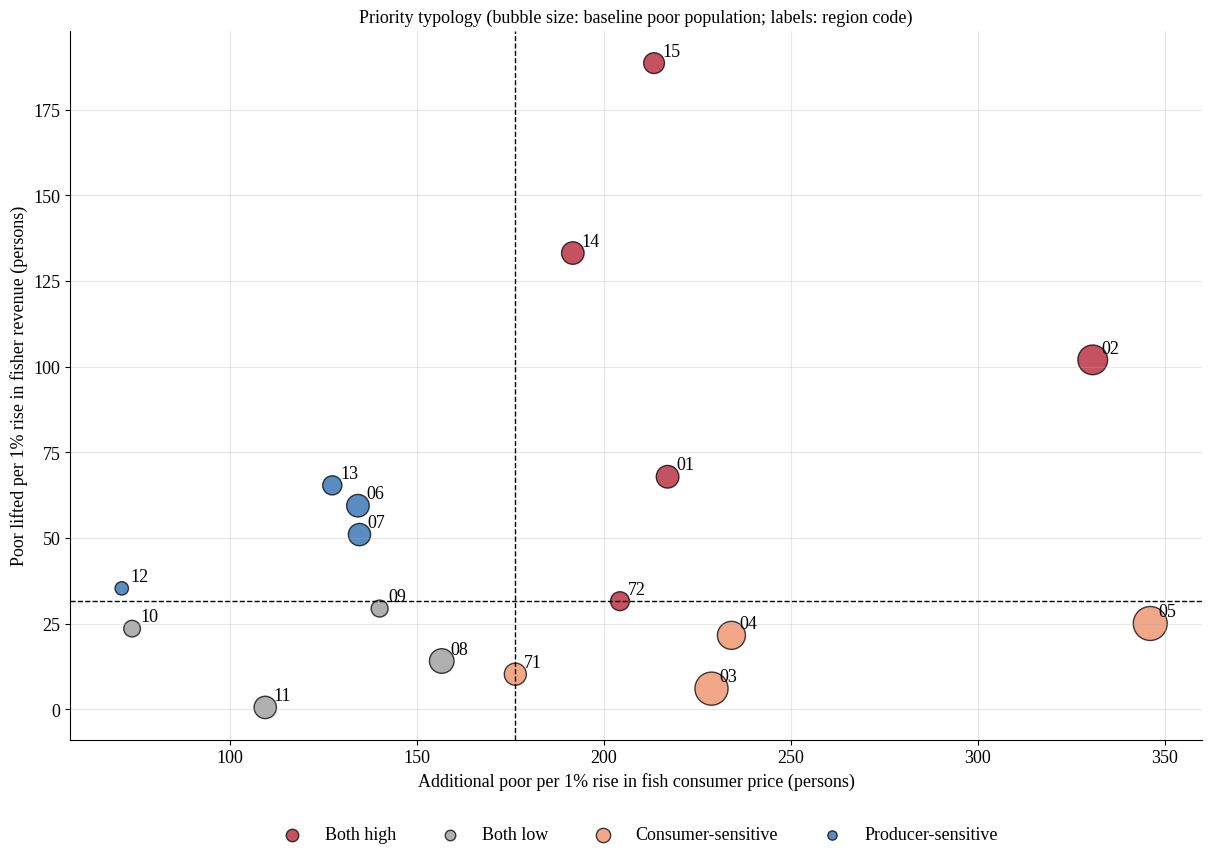

Kelompok peka harga konsumen dan penerimaan nelayan (5 wilayah): Muna, Buton, Buton Tengah, Buton Selatan, Kota
Baubau. Kelompok peka harga konsumen (4 wilayah): Konawe Selatan, Konawe, Kolaka, Kota Kendari. Kelompok peka
penerimaan nelayan (4 wilayah): Bombana, Wakatobi, Muna Barat, Konawe Kepulauan. Kelompok kepekaan rendah (4
wilayah): Kolaka Utara, Kolaka Timur, Buton Utara, Konawe Utara. Kenaikan harga ikan konsumen 1 persen menambah
penduduk miskin seluruh wilayah sekitar 3.091 orang, sedangkan kenaikan penerimaan nelayan 1 persen mengurangi
sekitar 865 orang. Kepekaan konsumen terbesar ada di Konawe Selatan dan kepekaan produsen terbesar di Buton
Selatan.



In [10]:
_, sens_c = dampak({'c': 1.01, 'p': 1.0, 'K': 1.0, 'r': 1.0}, prof, PARAM, produsen=False)
_, sens_p = dampak({'c': 1.0, 'p': 1.01, 'K': 1.0, 'r': 1.0}, prof, PARAM, produsen=True)
prof['sens_consumer'] = sens_c
prof['sens_producer'] = -sens_p
mc, mp = np.median(sens_c), np.median(-sens_p)
def kelas(sc, sp):
    if sc >= mc and sp >= mp:
        return 'Both high', 'Stabilise consumer prices and support fisher income'
    if sc >= mc:
        return 'Consumer-sensitive', 'Consumer price stabilisation (logistics, market operations)'
    if sp >= mp:
        return 'Producer-sensitive', 'Fisher income support (demand absorption, cold chain, processing)'
    return 'Both low', 'Monitoring'
kl = [kelas(a_, b_) for a_, b_ in zip(prof['sens_consumer'], prof['sens_producer'])]
prof['typology'] = [k_[0] for k_ in kl]
prof['instrument'] = [k_[1] for k_ in kl]
K07 = prof[['code', 'region_name', 'cluster', 'poor_base', 'sens_consumer', 'sens_producer', 'typology', 'instrument']].rename(columns={
    'code': 'Code', 'region_name': 'Regency/city', 'cluster': 'Cluster', 'poor_base': f'Baseline poor population {PER_PROV[:4]}',
    'sens_consumer': 'Additional poor per 1% rise in fish consumer price', 'sens_producer': 'Poor lifted per 1% rise in fisher revenue',
    'typology': 'Typology', 'instrument': 'Suggested instrument'}).sort_values(['Typology', f'Baseline poor population {PER_PROV[:4]}'], ascending=[True, False])
simpan_tabel(K07.round(3), 'K07_priority_typology', 'Priority typology of regencies/cities')
display(K07.round(2))

fig, ax = plt.subplots(figsize=(12, 8.5), constrained_layout=True)
warna = {'Both high': '#b2182b', 'Consumer-sensitive': '#ef8a62', 'Producer-sensitive': '#2166ac', 'Both low': '#969696'}
for t_, d_ in prof.groupby('typology'):
    ax.scatter(d_['sens_consumer'], d_['sens_producer'], s=d_['poor_base'] / 60, color=warna[t_], alpha=0.75, edgecolors='black', label=t_)
ax.axvline(mc, color='black', ls='--', lw=1)
ax.axhline(mp, color='black', ls='--', lw=1)
label_titik(ax, prof['sens_consumer'].to_numpy(), prof['sens_producer'].to_numpy(), prof['code'].to_numpy())
ax.set_xlabel('Additional poor per 1% rise in fish consumer price (persons)')
ax.set_ylabel('Poor lifted per 1% rise in fisher revenue (persons)')
ax.set_title('Priority typology (bubble size: baseline poor population; labels: region code)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, markerscale=0.5)
simpan_gambar(fig, 'K07_priority_typology', 'Priority typology of regencies/cities')

kal = []
for t_ in ['Both high', 'Consumer-sensitive', 'Producer-sensitive', 'Both low']:
    d_ = prof[prof['typology'] == t_]
    if len(d_):
        kal.append(f"Kelompok {TIPE_ID[t_]} ({len(d_)} wilayah): " + ', '.join(d_.sort_values('poor_base', ascending=False)['region_name']) + ".")
kal.append(f"Kenaikan harga ikan konsumen 1 persen menambah penduduk miskin seluruh wilayah sekitar {angka(sens_c.sum(), 0)} orang, "
           f"sedangkan kenaikan penerimaan nelayan 1 persen mengurangi sekitar {angka(-sens_p.sum(), 0)} orang. "
           f"Kepekaan konsumen terbesar ada di {prof.loc[prof['sens_consumer'].idxmax(), 'region_name']} dan kepekaan produsen terbesar di {prof.loc[prof['sens_producer'].idxmax(), 'region_name']}.")
tafsir('K07', ' '.join(kal))

## Langkah 9. Menyimpan dan memaketkan keluaran

In [11]:
with pd.ExcelWriter(os.path.join(OUT_DIR, 'tables_kabkota.xlsx')) as xw:
    pd.DataFrame([{'Sheet': k_, 'Title': v_[0]} for k_, v_ in TABEL.items()]).to_excel(xw, sheet_name='INDEX', index=False)
    for k_, (judul, df_) in TABEL.items():
        df_.to_excel(xw, sheet_name=k_[:31], index=False)
with open(os.path.join(SUB['interpretations'], 'interpretasi_otomatis_kabkota.md'), 'w', encoding='utf-8') as f:
    f.write('# Interpretasi otomatis: dampak kabupaten/kota\n\n')
    for k_, daftar in TAFSIR.items():
        f.write(f'## {k_}\n\n' + '\n\n'.join(daftar) + '\n\n')
pd.DataFrame([{'Type': 'Table', 'Code': k_, 'Title': v_[0]} for k_, v_ in TABEL.items()] +
             [{'Type': 'Figure', 'Code': k_, 'Title': v_[0]} for k_, v_ in GAMBAR.items()]).to_csv(os.path.join(OUT_DIR, 'manifest.csv'), index=False)
with open(os.path.join(OUT_DIR, 'run_settings_kabkota.json'), 'w', encoding='utf-8') as f:
    json.dump({'target_month': TARGET_BULAN, 'baseline_period': PER_PROV, 'scale_factor': float(SKALA),
               'reference_cpi_region': {str(k): int(v) for k, v in REF.items()}, 'font': FONT_UTAMA}, f, indent=2)
zip_path = shutil.make_archive(os.path.join(BASE_DIR, 'output_forkestra2026_kabkota'), 'zip', OUT_DIR)
print('Tabel:', len(TABEL), '| Gambar:', len(GAMBAR), '| Berkas ZIP:', zip_path)
if DI_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    from IPython.display import FileLink, display
    display(FileLink(os.path.relpath(zip_path)))

Tabel: 7 | Gambar: 7 | Berkas ZIP: /content/output_forkestra2026_kabkota.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Daftar pustaka

Badan Pusat Statistik. (2020). *Diagram timbang indeks harga konsumen hasil Survei Biaya Hidup 2018* (Buku 4). Badan Pusat Statistik. https://www.bps.go.id

Badan Pusat Statistik Provinsi Sulawesi Tenggara. (2026, 5 Agustus). *Persentase penduduk miskin Maret 2026 turun menjadi 10,02 persen* [Berita Resmi Statistik]. https://sultra.bps.go.id/id/pressrelease

Dey, M. M., Garcia, Y. T., Kumar, P., Piumsombun, S., Haque, M. S., Li, L., Radam, A., Senaratne, A., Khiem, N. T., & Koeshendrajana, S. (2008). Demand for fish in Asia: A cross-country analysis. *Australian Journal of Agricultural and Resource Economics, 52*(3), 321-338. https://doi.org/10.1111/j.1467-8489.2008.00418.x

International Monetary Fund, International Labour Organization, Eurostat, United Nations Economic Commission for Europe, Organisation for Economic Co-operation and Development, & World Bank. (2020). *Consumer price index manual: Concepts and methods*. International Monetary Fund. https://www.elibrary.imf.org/display/book/9781484354841/9781484354841.xml

Kementerian Kelautan dan Perikanan. (2026). *Portal data kelautan dan perikanan* [Data set]. https://portaldata.kkp.go.id

López, J. H., & Servén, L. (2006). *A normal relationship? Poverty, growth, and inequality* (Policy Research Working Paper No. 3814). World Bank. https://doi.org/10.1596/1813-9450-3814

OCHA, & Humanitarian Data Exchange. (2025). *Indonesia: Subnational administrative boundaries (COD-AB)* [Data set]. https://data.humdata.org/dataset/cod-ab-idn

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Irwin/McGraw-Hill.